<img src='../_images/logos/feature-engine.webp' width="400px">

# Feature-Engine - Topic 04 - Handle Numerical Variable Transformation

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png">

## Topic Objectives

* Handle Numerical Variable Transformation, using Log Transformer, Reciprocal Transformer, Power Transformer, Box-Cox and Yeo Johnson Transformer

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png">

## Import Packages for Learning

And load our typical packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.pipeline import Pipeline

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Handle Numerical Variable Transformation

The techniques presented here transform numerical variables considering multiple mathematical transformations. The idea is to transform the variable distribution, ideally to become close to a [normal distribution](https://en.wikipedia.org/wiki/Normal_distribution). We will study the following transformers:
* LogTransformer
* ReciprocalTransformer
* PowerTransformer
* BoxCoxTransformer
* YeoJohnsonTransformer

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png">

 We will do exercises with all of the transformers. You don't have to memorise the specific mathematical function for each transformer. Instead, you should be aware that we apply mathematical functions to numerical data. Later on, we will show a custom function that displays a report on numerical transformations, giving you criteria to select the most suitable transformer for your data.

* We will use the pingouin package to run a Q-Q plot to visually check how close to the normal distribution a given variable is.

In [2]:
import pingouin as pg

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

#### Log Transformer

It applies the [natural logarithm](https://en.wikipedia.org/wiki/Natural_logarithm) (base e) or the base 10 logarithm to numerical variables. The function documentation is [here](https://feature-engine.trainindata.com/en/latest/user_guide/transformation/LogTransformer.html)
* The transformer, as we may expect, can't handle zero or negative values
* The arguments are the `variables` you want to apply the method to. In cases where you don't pass in a list of variables, the transformer considers all numerical variables. The next argument is `base` (either 'e' or '10').

In [3]:
from feature_engine import transformation as vt

We will consider the California dataset from [scikit learn datasets](https://scikit-learn.org/stable/datasets/real_world.html). It shows median house values in California.
* We used four lines of code to unpack the dataset into a format to reach a DataFrame with all the features and the target variable. In the future lesson, we will investigate how to use sklearn functionalities. For now, we need its dataset.
* For this exercise, we are not interested in making sense of the variable's meaning and business impact. We're looking for numerical variables for handling transformation. we will consider only a subset of the variables.

In [4]:
from sklearn.datasets import fetch_openml
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)

df = df.filter(['MedInc','AveRooms', 'target'])
df.head()

,target
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


We assess the histogram and QQ plot by looping over the variables. We create custom functions for this task since we will repeat it across different transformers. The first will calculate skewness and kurtosis. The second plots a histogram and QQ plot for a given numerical variable.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

A quick recap
* Skewness is the asymmetry of the data. A distribution is symmetric when it looks the same to the left and right of the centre point. It is horizontally mirrored. Positive Skewness happens when the tail on the right side is longer. Negative skewness is the opposite.
* Kurtosis relates to the tails of the distribution. It is a measure of outliers in the distribution. A negative kurtosis indicates the distribution has thin tails. Positive kurtosis indicates that the distribution is peaked and has thick tails.

*** target ***


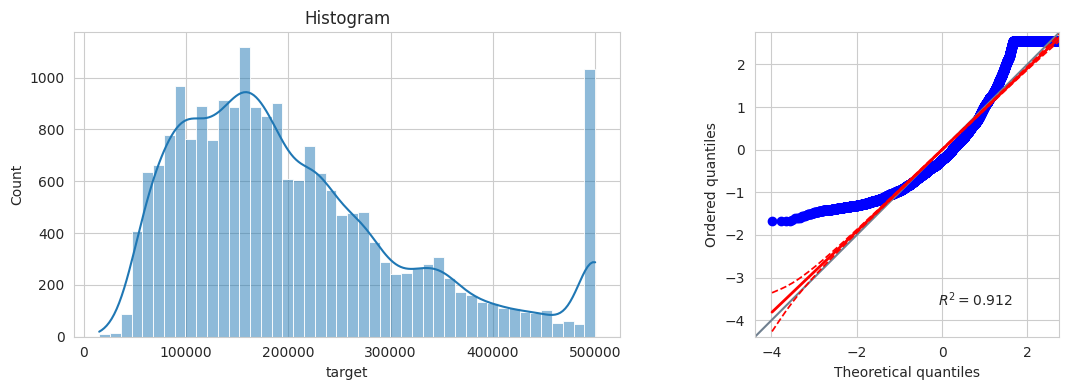

before apply transformation  | skewness: 0.98 | kurtosis: 0.33




In [5]:
def calculate_skew_kurtosis(df,col, moment):
  print(f"{moment}  | skewness: {df[col].skew().round(2)} | kurtosis: {df[col].kurtosis().round(2)}")


def distribution_before_applying_transformer(df):
  for col in df.columns:
    print(f"*** {col} ***")
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title("Histogram")
    pg.qqplot(df[col], dist='norm',ax=axes[1])
    plt.tight_layout()
    plt.show()
    calculate_skew_kurtosis(df,col,'before apply transformation')
    print("\n")

distribution_before_applying_transformer(df)

We set the pipeline with this transformer: `vt.LogTransformer()`. Then we `.fit_transform()` the pipeline, assigning the result to `df_transformed`

In [6]:
pipeline = Pipeline([
      ( 'log', vt.LogTransformer() )
  ])

df_transformed = pipeline.fit_transform(df)
df_transformed.head()

,target
0,13.022764
1,12.789684
2,12.771671
3,12.740517
4,12.743151


We now compare the distribution of the variables before and after applying the transformer. We create a custom function for that. It plots the histogram and QQplot for the same variable before and after applying the transformer.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Note: When transforming variables, the summary statistics may change. We will consider here only skewness and kurtosis. What is important is to reach a gain where the transformed variable is closer to a normal distribution.


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Let's comment on the plots
* `MedInc` decreased skewness and changed from positive to negative, but its kurtosis decreased significantly. The QQ plot is closer to the diagonal line after transformation.
* `AveRooms` decreased skewness and its kurtosis decreased. The QQ plot is closer to the diagonal line after transformation, but it is still "bent".
* `target` decreased skewness and kurtosis. Skewness and kurtosis changed from positive to negative. The QQ plot is closer to the diagonal line after transformation.

We can say that, in general, this transformation helped to transform these variables to become closer to a normal distribution when we compare the distribution shape and QQ plot before and after applying the transformer.


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> 

However, we have more mathematical functions at our disposal to test. 
* That leads to another question: Which mathematical function should I apply to my variable? We prepared a custom function that will use all possible transformations in a given variable, so you can have a report to decide which transformer to apply.

*** target ***


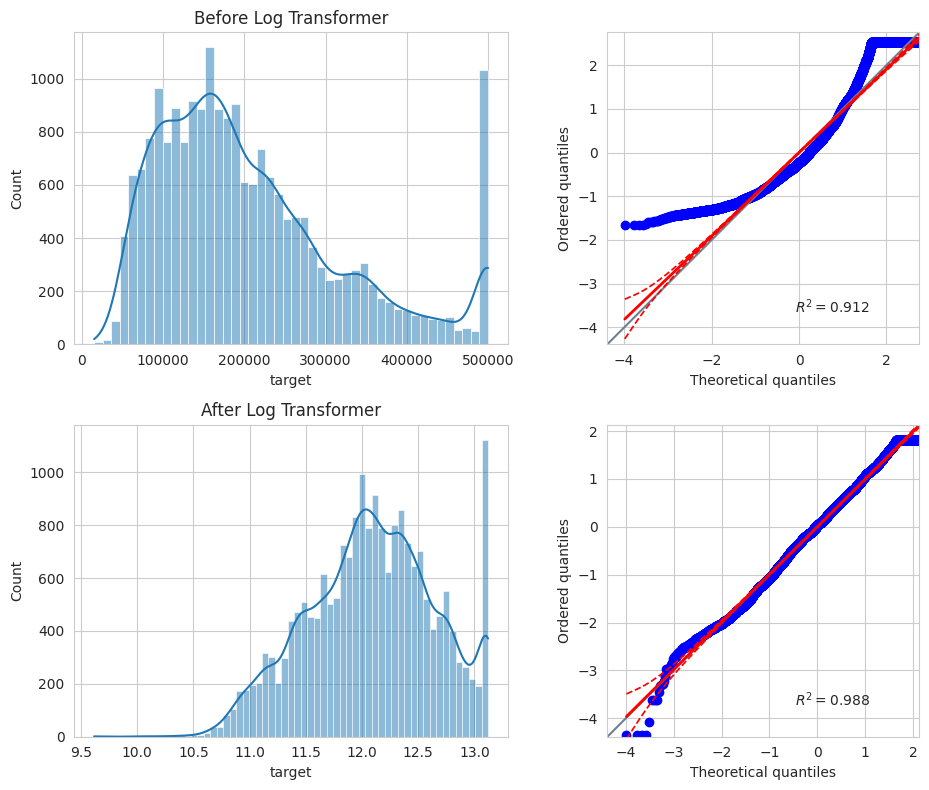

before transformation  | skewness: 0.98 | kurtosis: 0.33
after transformation  | skewness: -0.17 | kurtosis: -0.43




In [7]:
def compare_distributions_before_and_after_applying_transformer(df, df_transformed, method):

  for col in df.columns:
    print(f"*** {col} ***")
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

    sns.histplot(data=df, x=col, kde=True, ax=axes[0,0])
    axes[0,0].set_title(f'Before {method}')
    pg.qqplot(df[col], dist='norm',ax=axes[0,1])
    
    sns.histplot(data=df_transformed, x=col, kde=True, ax=axes[1,0])
    axes[1,0].set_title(f'After {method}')
    pg.qqplot(df_transformed[col], dist='norm',ax=axes[1,1])
    
    plt.tight_layout()
    plt.show()

    calculate_skew_kurtosis(df,col, moment='before transformation')
    calculate_skew_kurtosis(df_transformed,col, moment='after transformation')
    print("\n")


compare_distributions_before_and_after_applying_transformer(df, df_transformed, method='Log Transformer')

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

#### Reciprocal Transformer

This technique applies the reciprocal transformation 1 / x to numerical variables. As we may expect, it can't handle a variable that contains zero. The function documentation is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/transformation/ReciprocalTransformer.html)
* The argument is `variables`. In cases where you don't pass in a list of variables, the transformer considers all numerical variables.

In [8]:
from feature_engine import transformation as vt

We consider the California dataset with the same variables from the previous exercise.

In [9]:
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)

df = df.filter(['MedInc','AveRooms', 'target'])
df.head()

,target
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


We assess the distribution using the previous custom function.

*** target ***


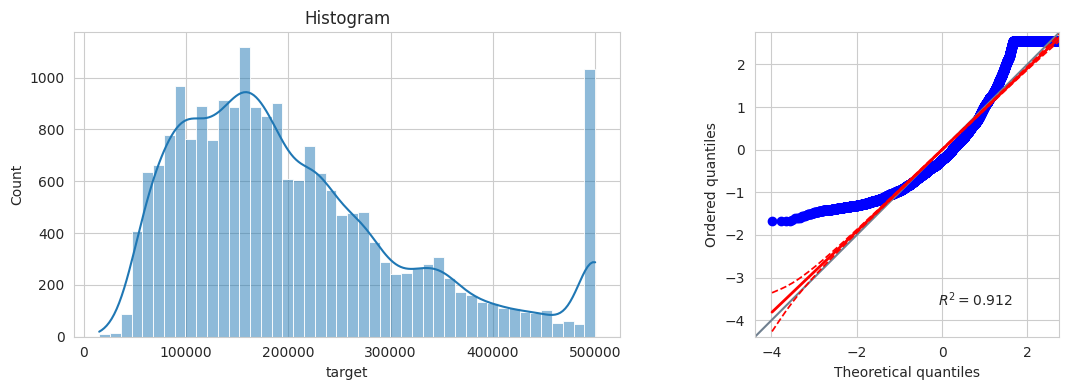

before apply transformation  | skewness: 0.98 | kurtosis: 0.33




In [10]:
distribution_before_applying_transformer(df)

We set the pipeline with this transformer: `vt.ReciprocalTransformer()`. Then we `.fit_transform()` the pipeline, assigning the result to `df_transformed`

In [11]:
pipeline = Pipeline([
    ( 'reciprocal', vt.ReciprocalTransformer() )
])

df_transformed = pipeline.fit_transform(df)
df_transformed.head()

,target
0,0.000002
1,0.000003
2,0.000003
3,0.000003
4,0.000003


We compare the histograms and QQ plots before and after applying the transformers.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Let's comment on the plots.
* ``MedInc`` increased skewness, and kurtosis. The QQ plots look similar. It doesn't look to have made any progress after transforming.
* `AveRooms` decreased both skewness and kurtosis. It doesn't look to have made much progress after transforming.
* `target` increases both skewness and kurtosis. It doesn't look to have made any progress after transforming.

*** target ***


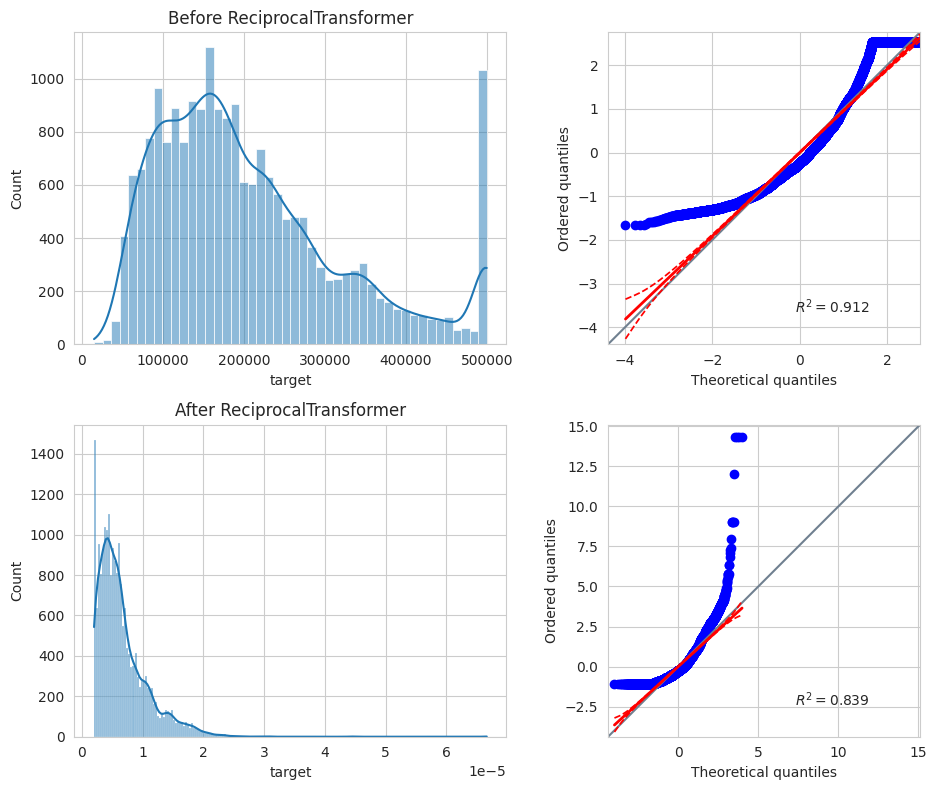

before transformation  | skewness: 0.98 | kurtosis: 0.33
after transformation  | skewness: 2.21 | kurtosis: 12.97




In [12]:
compare_distributions_before_and_after_applying_transformer(df, df_transformed, method='ReciprocalTransformer')

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

####  Power Transformer

It applies power or exponential transformations to the numerical variable. The documentation is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/transformation/PowerTransformer.html)
* The arguments are the `variables` you want to apply the method to. In cases where you don't pass in a list of variables, the transformer considers all numerical variables. `exp` is the power of the exponent, and the default is 0.5

In [13]:
from feature_engine import transformation as vt

We consider the California dataset with the same variables from the previous exercise.

In [14]:
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)

df = df.filter(['MedInc','AveRooms', 'target'])
df.head()

,target
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


We assess the distribution using the previous custom function.

*** target ***


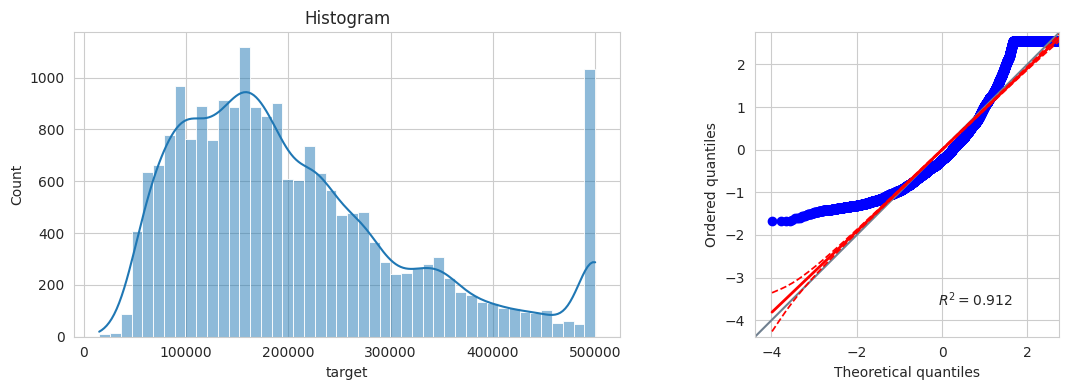

before apply transformation  | skewness: 0.98 | kurtosis: 0.33




In [15]:
distribution_before_applying_transformer(df)

We set the pipeline with this transformer: `vt.PowerTransformer()`. Then we `.fit_transform()` the pipeline, assigning the result to `df_transformed`

In [16]:
pipeline = Pipeline([
      ('pt', vt.PowerTransformer() )
  ])

df_transformed = pipeline.fit_transform(df)
df_transformed.head()

,target
0,672.755528
1,598.748695
2,593.380148
3,584.208867
4,584.978632


We compare the histograms and QQ plots before and after applying the transformers.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Let's comment on the plots.
* `MedInc` decreased skewness and kurtosis. The QQ plots look better but still 'bent' after transforming. 
* `AveRooms` decreased skewness and kurtosis. The QQ plots look better but still 'bent' after transforming.
* `target` decreased skewness and kurtosis moved from positive to negative. It looks to have made minor progress when comparing the QQ plot before and after the transformation since the blue dots are close to the diagonal line.

*** target ***


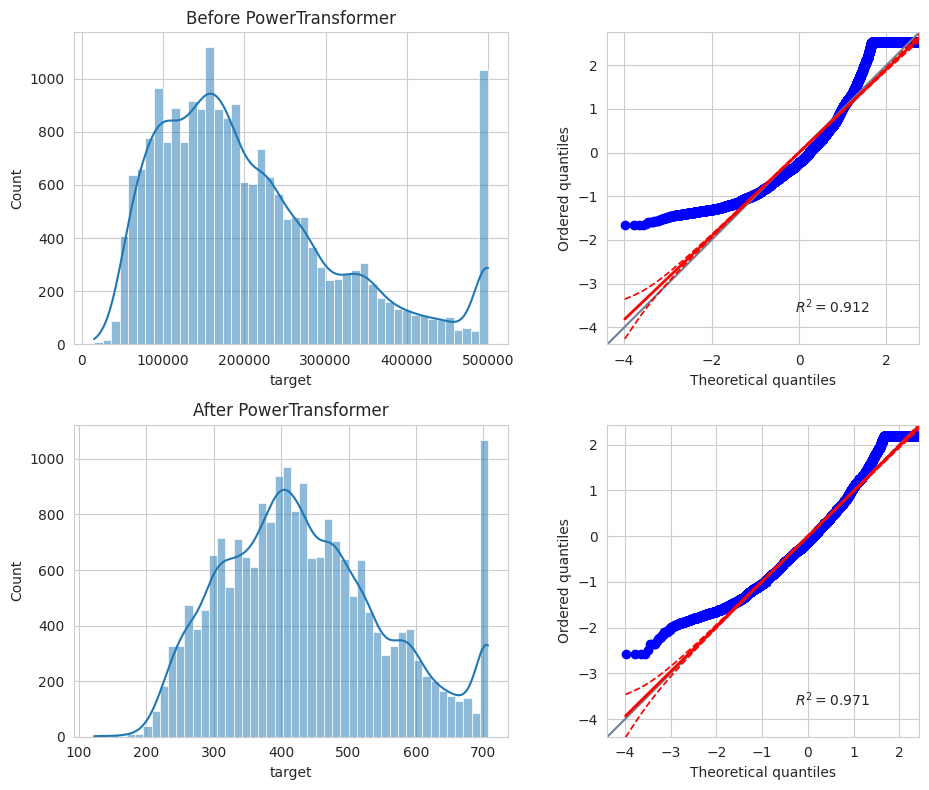

before transformation  | skewness: 0.98 | kurtosis: 0.33
after transformation  | skewness: 0.44 | kurtosis: -0.42




In [17]:
compare_distributions_before_and_after_applying_transformer(df, df_transformed, method='PowerTransformer')

---

 <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

####  Box Cox Transformer

It applies the BoxCox transformation to numerical variables. A mathematical formulation can be found [here](https://www.statisticshowto.com/box-cox-transformation/). The data must be positive for the transformer. The documentation for the function is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/transformation/BoxCoxTransformer.html)
* The argument is `variables`. In cases where you don't pass in a list of variables, the transformer considers all numerical variables. 

In [18]:
from feature_engine import transformation as vt

We consider the California dataset with the same variables from the previous exercise.

In [19]:
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)

df = df.filter(['MedInc','AveRooms', 'target'])
df.head()

,target
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


We assess the distribution using the previous custom function.

*** target ***


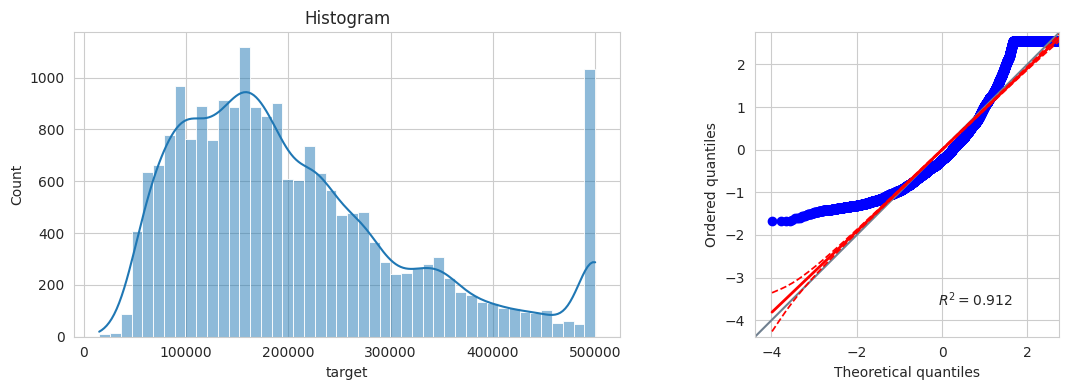

before apply transformation  | skewness: 0.98 | kurtosis: 0.33




In [20]:
distribution_before_applying_transformer(df)

We set the pipeline with this transformer: `vt.BoxCoxTransformer()`. Then we `.fit_transform()` the pipeline, assigning the result to `df_transformed`

In [21]:
pipeline = Pipeline([
      ('bct', vt.BoxCoxTransformer() )
  ])

df_transformed = pipeline.fit_transform(df)
df_transformed.head()

,target
0,32.675416
1,31.509295
2,31.420575
3,31.267609
4,31.280517


We compare the histograms and QQ plots before and after applying the transformers.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Let's comment on the plots.
* `MedInc` decreased skewness to zero, and kurtosis decreased significantly. It's made an improvement when you look at the QQ plot.
* `AveRooms` decreased skewness from positive to negative, and kurtosis decreased significantly. It's made an improvement when you look at the QQ plot albeit still 'bent'.
* `target` decreased skewness from positive to negative and kurtosis went from from positive to negative. It looks to have made minor progress when comparing the QQ plot before and after the transformation since the blue dots are close to the diagonal line.

*** target ***


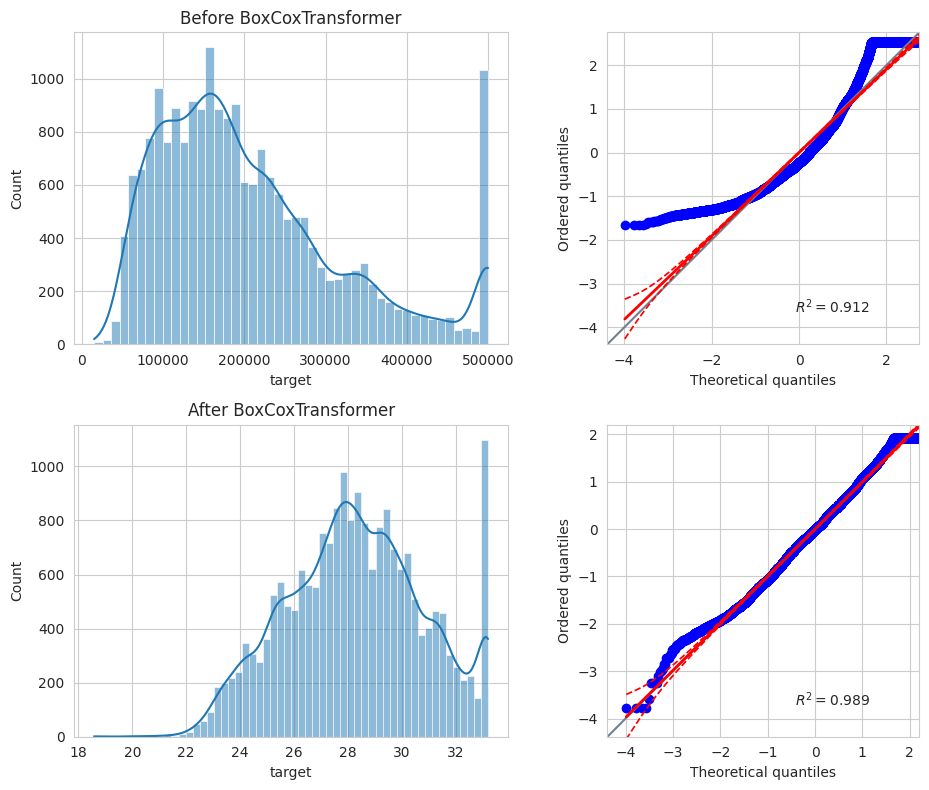

before transformation  | skewness: 0.98 | kurtosis: 0.33
after transformation  | skewness: -0.01 | kurtosis: -0.52




In [22]:
compare_distributions_before_and_after_applying_transformer(df, df_transformed, method='BoxCoxTransformer')

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

#### Yeo Johnson Transformer

It applies the Yeo-Johnson transformation. More information on the mathematical formulation can be found [here](https://statisticaloddsandends.wordpress.com/2021/02/19/the-box-cox-and-yeo-johnson-transformations-for-continuous-variables/). The documentation for the function is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/transformation/YeoJohnsonTransformer.html).
* The argument is a list of `variables`. In cases where you don't pass in a list of variables, the transformer considers all numerical variables.

In [23]:
from feature_engine import transformation as vt

We consider the California dataset with the same variables from the previous exercise.

In [24]:
california_data = fetch_openml(data_id=44977, as_frame=True)  # california_housing on OpenML
df = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df['target'] = pd.Series(california_data.target)

df = df.filter(['MedInc','AveRooms', 'target'])
df.head()

,target
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


We assess the distribution using the previous custom function.

*** target ***


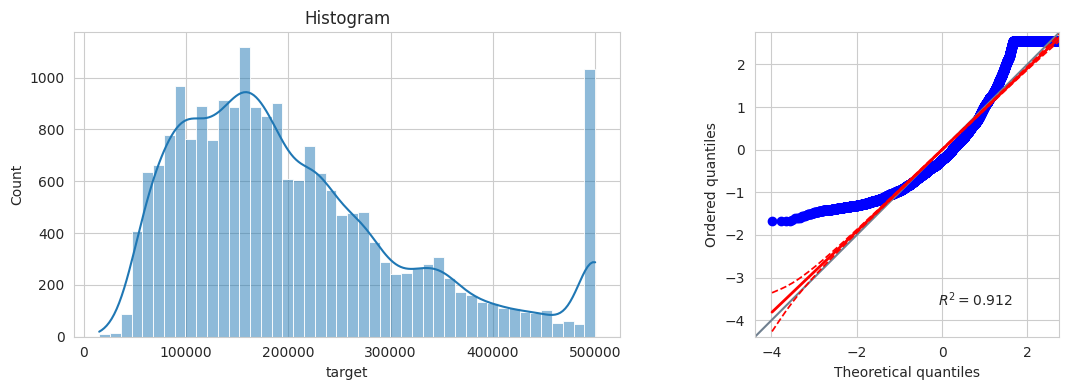

before apply transformation  | skewness: 0.98 | kurtosis: 0.33




In [25]:
distribution_before_applying_transformer(df)

We set the pipeline with this transformer: `vt.YeoJohnsonTransformer()`. Then we `.fit_transform()` the pipeline, assigning the result to `df_transformed`

In [26]:
pipeline = Pipeline([
      ('yj', vt.YeoJohnsonTransformer() )
  ])

df_transformed = pipeline.fit_transform(df)
df_transformed.head()

,target
0,32.673926
1,31.507891
2,31.419178
3,31.266224
4,31.279130


We compare the histograms and QQ plots before and after applying the transformers.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Let's comment on the plots.
* `MedInc` decreased skewness and kurtosis. The QQ plots are much improved. 
* `AveRooms` decreased skewness from positive to negative, and kurtosis decreased significantly. It's made an improvement when you look at the QQ plot albeit still 'bent'.
* `target` decreased skewness but kurtosis worsened from positive to negative. The QQ plot after the transformation looks better than before the transformation.

*** target ***


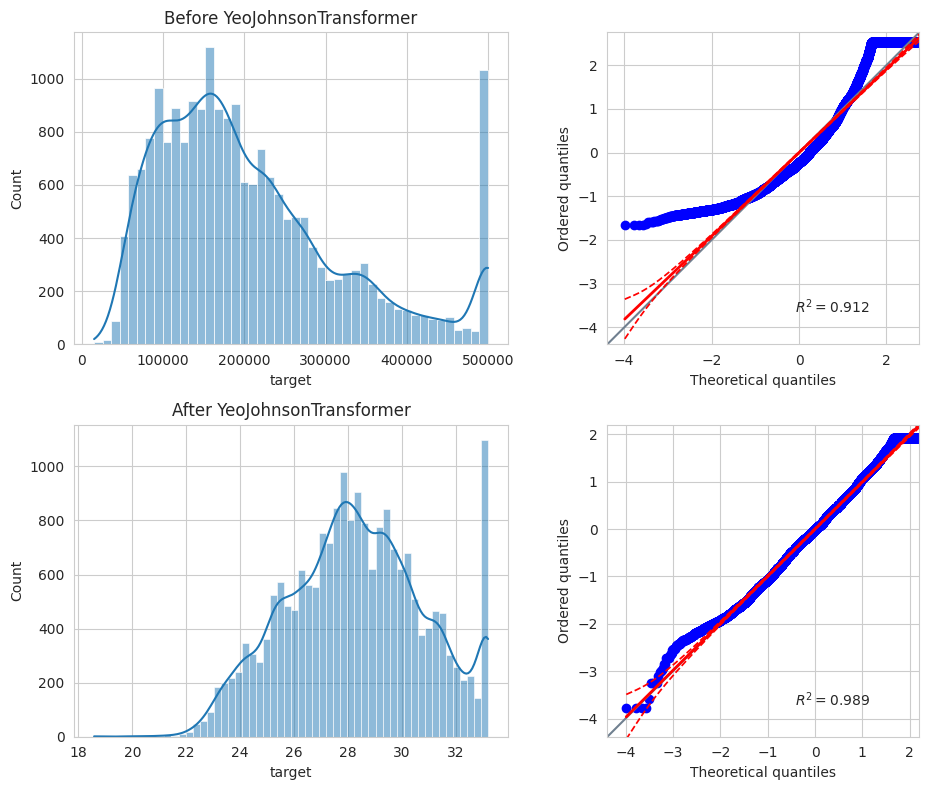

before transformation  | skewness: 0.98 | kurtosis: 0.33
after transformation  | skewness: -0.01 | kurtosis: -0.52




In [27]:
compare_distributions_before_and_after_applying_transformer(df, df_transformed, method='YeoJohnsonTransformer')